# Sliding-p time-data analysis

This notebook loads the per-initial-condition CSV files produced by the matching time-data Julia script.


In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 16,
})


def float_str(f):
    return str(float(f)).replace(".", "p")


In [9]:
# These controls mirror get_time_random_slidding_p_time_data.jl.
L_vals = [20000]
upper_val = 0.42
lower_val = round(upper_val / 10, ndigits=6)
p_c = 0.494
p_rate = 0.0005
p_vals = [round(0.492 + i * 0.00005, 6) for i in range(-3, 4)] + [round(p_c + i * p_rate, 6) for i in range(-3, 0)]
upper_epsilons = [upper_val] * len(p_vals)
lower_epsilons = [lower_val] * len(p_vals)

control_vals = p_vals
control_label = r"$p$"
model_label = r"Time-Random Sliding $p$"
time_prefact = 100
time_step = 2000
num_initial_conds = 2000
num_init_conds_offset = 0
initial_state_prob = 0.5
DATA_ROOT = Path("data/time_rand_slidding_p/rho_per_time/IC1")
DATA_ROOT = Path("/Volumes/ExternalData/stavskya_mc/data/time_rand_slidding_p/rho_per_time/IC1")
FIG_ROOT = Path("figs/time_random/slidding_p")
FIG_ROOT.mkdir(parents=True, exist_ok=True)


def sample_path(L_val, upper_ep, lower_ep, p_val, init_cond):
    upper_name, lower_name, p_name = map(float_str, (upper_ep, lower_ep, p_val))
    return DATA_ROOT / f"L{L_val}" / f"epsilonu{upper_name}" / f"epsilonl{lower_name}" / f"pval{p_name}" / (
        f"IC1_L{L_val}_epsilonu{upper_name}_epsilonl{lower_name}_pval{p_name}_"
        f"timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv"
    )


In [3]:
# Load every available initial-condition trajectory and calculate mean and SEM.
mean_rhos = {}
sem_rhos = {}
time_vals = {}
loaded_counts = {}

for L_val in L_vals:
    for control_val, upper_ep, lower_ep, p_val in zip(control_vals, upper_epsilons, lower_epsilons, p_vals):
        trajectories = []
        times = None
        for init_cond in range(1 + num_init_conds_offset, num_initial_conds + 1 + num_init_conds_offset):
            filepath = sample_path(L_val, upper_ep, lower_ep, p_val, init_cond)
            if not filepath.exists():
                continue
            sample_df = pd.read_csv(filepath)
            if times is None:
                times = sample_df["time"].to_numpy()
            trajectories.append(sample_df["rho"].to_numpy())
        if not trajectories:
            raise FileNotFoundError(f"No trajectories found for L={L_val}, {control_label}={control_val}")
        trajectories = np.asarray(trajectories)
        key = (L_val, control_val)
        time_vals[key] = times
        mean_rhos[key] = trajectories.mean(axis=0)
        sem_rhos[key] = trajectories.std(axis=0, ddof=1) / np.sqrt(len(trajectories))
        loaded_counts[key] = len(trajectories)

loaded_counts


{(20000, 0.49185): 2000,
 (20000, 0.4919): 2000,
 (20000, 0.49195): 2000,
 (20000, 0.492): 2000,
 (20000, 0.49205): 2000,
 (20000, 0.4921): 2000,
 (20000, 0.49215): 2000,
 (20000, 0.4925): 2000,
 (20000, 0.493): 2000,
 (20000, 0.4935): 2000,
 (20000, 0.494): 2000,
 (20000, 0.4945): 2000,
 (20000, 0.495): 2000,
 (20000, 0.4955): 2000}

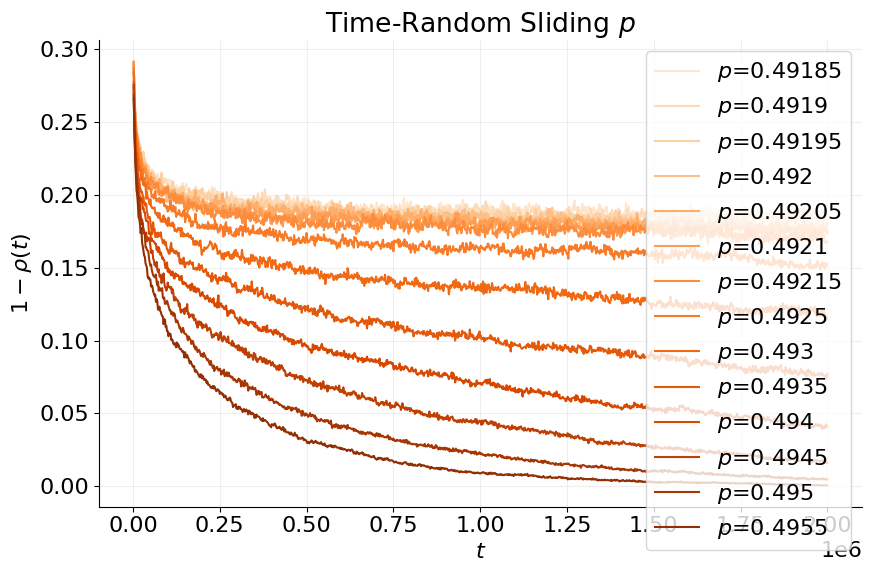

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
for L_val in L_vals:
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        ax.plot(time_vals[key], 1 - mean_rhos[key], color=cmap(i + 2), label=fr"{control_label}={control_val}")
ax.set_title(model_label)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$1 - \rho(t)$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_ROOT / "rho_per_time.png", dpi=200)
plt.show()


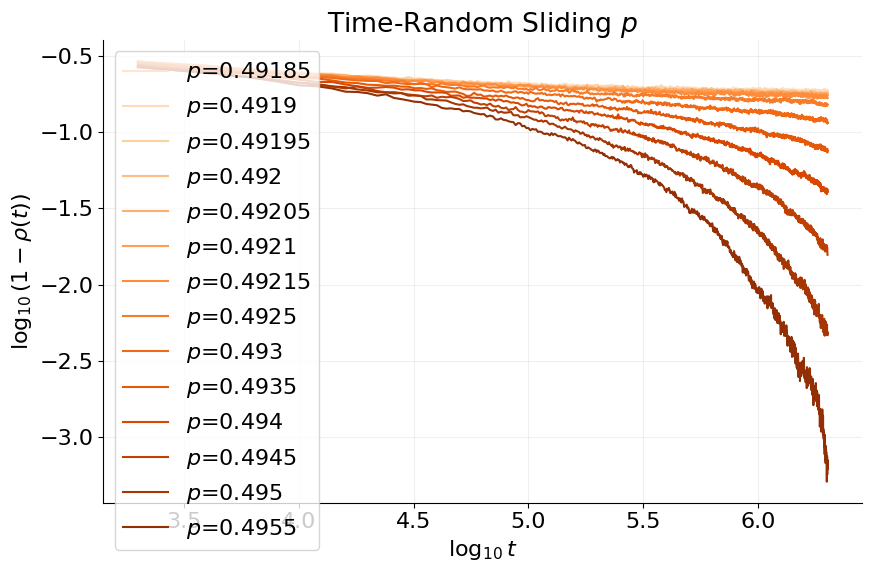

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
for L_val in L_vals:
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log10(time_vals[key][positive]), np.log10((1 - mean_rhos[key])[positive]),
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
ax.set_title(model_label)
ax.set_xlabel(r"$\log_{10} t$")
ax.set_ylabel(r"$\log_{10}(1 - \rho(t))$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_ROOT / "rho_per_time_log.png", dpi=200)
plt.show()


In [7]:
def log_b(x, b):
    return np.log(x) / np.log(b)

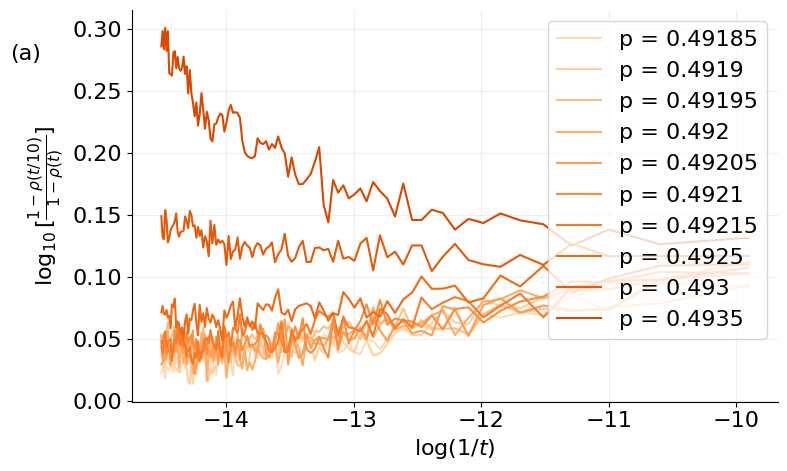

In [10]:
b = 10
delta_guess = 0.105
fig=plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    for i, control_val in enumerate(control_vals):
        c = cmap(i+3)
        key = (L_val, control_val)
        l_time_vals = [t * b for t in time_vals[key] if t*b <=max(time_vals[key])]
        data_to_plot = 1 - mean_rhos[key]
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step)) -1] for t in l_time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[((t)//time_step) -1] for t in l_time_vals])
        data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)
        plt.plot(
            np.log((1/np.array(l_time_vals))), 
            data_to_plot, 
            label = fr"p = {control_val}",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
    # plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
    # plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
    plt.text(0.01, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$\log(1/t)$")
    plt.ylabel(r"$\log_{10}[\frac{1-\rho(t/10)}{1-\rho(t)}]$")
    plt.legend()
    # plt.xlim((np.log(0.000005), np.log(0.0005)))
    # plt.ylim((0.01, 0.25))
    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta.png")
    plt.show()